# 16 - Árvore Binária

### Desenhar árvore vertical

In [ ]:
# ------------------------------------------------------------
# Função para desenhar a árvore em formato de texto (ASCII)
# ------------------------------------------------------------
def desenhar_arvore_vertical(raiz):
    linhas, *_ = _desenhar_rec(raiz)  # Monta o desenho da árvore

    # Percorre cada linha do desenho
    for linha in linhas:
        print(linha)                  # Imprime cada linha


# Função recursiva que monta o desenho
def _desenhar_rec(no):
    # Se o nó for vazio
    if no is None:
        return [" "], 1, 1, 0

    # Se for folha
    if no.esquerda is None and no.direita is None:
        linha = f"|{no.chave}|"
        largura = len(linha)
        return [linha], largura, 1, largura // 2

    esquerda, largura_esq, altura_esq, meio_esq = _desenhar_rec(no.esquerda)
    direita, largura_dir, altura_dir, meio_dir = _desenhar_rec(no.direita)

    valor = f"|{no.chave}|"
    largura_valor = len(valor)

    primeira_linha = " " * (meio_esq + 1) + "_" * (largura_esq - meio_esq - 1)
    primeira_linha += valor
    primeira_linha += "_" * meio_dir + " " * (largura_dir - meio_dir)

    segunda_linha = " " * meio_esq + "/" + " " * (largura_esq - meio_esq - 1 + largura_valor + meio_dir) + "\\"
    segunda_linha += " " * (largura_dir - meio_dir - 1)

    if altura_esq < altura_dir:
        esquerda += [" " * largura_esq] * (altura_dir - altura_esq)
    elif altura_dir < altura_esq:
        direita += [" " * largura_dir] * (altura_esq - altura_dir)

    linhas = [primeira_linha, segunda_linha]

    for e, d in zip(esquerda, direita):
        linhas.append(e + " " * largura_valor + d)

    return linhas, largura_esq + largura_valor + largura_dir, max(altura_esq, altura_dir) + 2, largura_esq + largura_valor // 2

## 16.1. Class e Testes

In [ ]:
# O que esse código faz (resumo rápido)
# Implementa: Inserção, Busca, Remoção, Percurso em ordem, Impressão da árvore, Encontrar mínimo, Estrutura BST completa,

# ------------------------------------------------
# Classe que representa um nó da árvore
# ------------------------------------------------
class Nodo:
    # Construtor do nó ------------------------------------------------
    def __init__(self, chave):
        self.chave = chave        # Armazena o valor do nó
        self.esquerda = None      # Ponteiro para o filho da esquerda
        self.direita = None       # Ponteiro para o filho da direita


# ------------------------------------------------
# Classe da Árvore Binária de Busca (BST = Binary Search Tree)
# ------------------------------------------------
class BST:
    # Construtor da árvore ------------------------------------------------
    def __init__(self):
        self.raiz = None          # Inicializa a raiz como vazia

    # Função para inserir um valor ------------------------------------------------
    def inserir(self, chave):
        if self.raiz is None:           # Se a árvore estiver vazia
            self.raiz = Nodo(chave)     # Cria a raiz
        else:
            self._inserir_recursivo(self.raiz, chave)  # Chama inserção recursiva

    # Função auxiliar recursiva para inserir ------------------------------------------------
    def _inserir_recursivo(self, no_atual, chave):
        if chave < no_atual.chave:                  # Se a chave for menor vai para esquerda
            if no_atual.esquerda is None:           # Se não existir filho esquerdo
                no_atual.esquerda = Nodo(chave)     # Insere novo nó
            else:
                self._inserir_recursivo(no_atual.esquerda, chave)  # Continua recursão
        elif chave > no_atual.chave:                # Se a chave for maior vai para direita
            if no_atual.direita is None:            # Se não existir filho direito
                no_atual.direita = Nodo(chave)      # Insere novo nó
            else:
                self._inserir_recursivo(no_atual.direita, chave)   # Continua recursão

    # Função para buscar um valor -------------------------------------------------------
    def buscar(self, chave):
        return self._buscar_recursivo(self.raiz, chave)   # Chama busca recursiva

    # Função auxiliar de busca recursiva ------------------------------------------------
    def _buscar_recursivo(self, no_atual, chave):
        if no_atual is None or no_atual.chave == chave:     # Se chegou no fim ou encontrou a chave
            return no_atual
        if chave < no_atual.chave:          # Se a chave for menor
            return self._buscar_recursivo(no_atual.esquerda, chave)  # Busca à esquerda

        return self._buscar_recursivo(no_atual.direita, chave)       # Busca à direita

    # Função para remover um valor ------------------------------------------------------
    def remover(self, chave):
        self.raiz = self._remover_recursivo(self.raiz, chave)  # Chama remoção recursiva

    # Função auxiliar para remover recursivamente ----------------------------------------
    def _remover_recursivo(self, no_atual, chave):
        if no_atual is None:        # Se o nó não existe
            return no_atual

        # localizar o nó a ser removido, se a chave for menor
        if chave < no_atual.chave:
            no_atual.esquerda = self._remover_recursivo(no_atual.esquerda, chave)
        elif chave > no_atual.chave:        # Se a chave for maior
            no_atual.direita = self._remover_recursivo(no_atual.direita, chave)
        else:
            # casos 1 e 2: sem filhos ou com um filho
            if no_atual.esquerda is None:
                return no_atual.direita
            elif no_atual.direita is None:
                return no_atual.esquerda

            # caso 3: nó com dois filhos
            # obtemos o sucessor: menor valor da subárvore direita
            temp = self.minimo_valor_no(no_atual.direita)
            no_atual.chave = temp.chave
            # removemos o sucessor da subárvore direita
            no_atual.direita = self._remover_recursivo(no_atual.direita, temp.chave)

        return no_atual

    # Função para encontrar o menor valor de uma subárvore ------------------------------------------------
    def minimo_valor_no(self, no):
        atual = no   # Começa pelo nó recebido
        while atual.esquerda is not None:       # Enquanto existir filho à esquerda
            atual = atual.esquerda              # Vai para o filho da esquerda

        return atual   # Retorna o menor nó

    # Função para exibir em ordem (esquerda, raiz, direita) ------------------------------------------------
    def exibir_ordenado(self, no_atual):  # atravessamento em ordem simétrica
        if no_atual:        # Se o nó existir
            self.exibir_ordenado(no_atual.esquerda)  # Visita esquerda
            print(no_atual.chave, end=" ")           # Mostra a chave
            self.exibir_ordenado(no_atual.direita)   # Visita direita

    # Função para exibir a árvore em formato lateral ------------------------------------------------
    def exibir(self, no_atual=None, nivel=0):
        if no_atual is None and nivel == 0:     # Se for a primeira chamada
            no_atual = self.raiz

        if no_atual is not None:                # Se o nó existir
            self.exibir(no_atual.direita, nivel+1)          # Mostra direita primeiro
            print('   '*nivel + f'--> {no_atual.chave}')    # Mostra o nó
            self.exibir(no_atual.esquerda, nivel+1)         # Mostra esquerda

In [ ]:
# TESTANDO ------------------------------
bst = BST()   # Cria a árvore

elementos = [50, 30, 70, 20, 40, 60, 80]  # Lista de elementos a serem inseridos

# Inserindo elementos na árvore
for x in elementos:
    bst.inserir(x)

print("Árvore Gerada: ")
bst.exibir()                # Exibe a árvore

print("\nElementos em ordem crescente:")
bst.exibir_ordenado(bst.raiz)   # Exibe os elementos em ordem crescente

print("\n\nDesenho da árvore:")
desenhar_arvore_vertical(bst.raiz)                       # Desenha a árvore em forma vertical

Árvore Gerada: 
      --> 80
   --> 70
      --> 60
--> 50
      --> 40
   --> 30
      --> 20

Elementos em ordem crescente:
20 30 40 50 60 70 80 

Desenho da árvore:
       _____|50|______      
      /               \     
   _|30|__         _|70|__  
  /       \       /       \ 
|20|    |40|    |60|    |80|


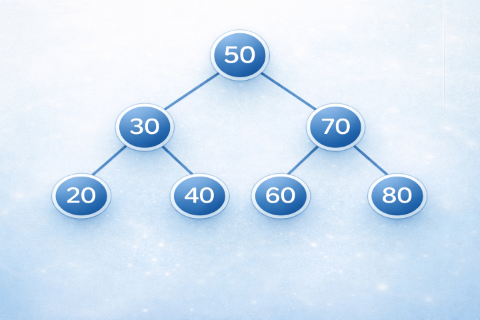

## 16.2. Exercícios da aula

In [ ]:
def criar_arvore(elementos, n, remover) :
    bst = BST()   # Cria a árvore

    # Inserindo elementos na árvore
    for x in elementos:
        bst.inserir(x)

    print("--------------------------------------------------------------------------------------------------")

    if remover is None:
        print(f"Árvore {n}:")
        desenhar_arvore_vertical(bst.raiz)                       # Desenha a árvore em forma vertical
    else:
        print(f"Árvore {n} - Removido o item {remover}:")
        bst.remover(remover)
        desenhar_arvore_vertical(bst.raiz)                       # Desenha a árvore em forma vertical

In [ ]:
# TESTANDO ------------------------------
# arvore 1 - Lista de elementos a serem inseridos
# elementos_arvore1 = [100, 200, 140, 50, 105, 70, 80, 30, 400, 350, 117, 80, 42, 65]
# criar_arvore(elementos_arvore1, 1)

# elementos_arvore2 = [8, 9, 11, 15, 19, 20, 21, 7, 3, 2, 1, 5, 6, 4, 13, 14, 10, 12, 17, 16, 18]
# criar_arvore(elementos_arvore2, 2)

# remover o item "70"
elementos_arvore3 = [500, 100, 700, 50, 200, 140, 400, 350, 30, 70, 20, 42, 65, 60, 68]
criar_arvore(elementos_arvore3, 3, None)
criar_arvore(elementos_arvore3, 3, 70)

# remover o item "100"
elementos_arvore4 = [500, 100, 700, 50, 200, 140, 400, 350, 30, 70, 20, 42, 65, 60, 68]
criar_arvore(elementos_arvore4, 4, None)
criar_arvore(elementos_arvore4, 4, 100)


--------------------------------------------------------------------------------------------------
Árvore 3:
                                    _______________________|500|__   
                                   /                              \  
               __________________|100|_______                   |700|
              /                              \                       
       _____|50|______________           __|200|_______              
      /                       \         /              \             
   _|30|__             _____|70|      |140|        __|400|           
  /       \           /         \                 /       \          
|20|    |42|       _|65|__                      |350|                
                  /       \                                          
                |60|    |68|                                         
--------------------------------------------------------------------------------------------------
Árvore 3 - Removido o 

###

#
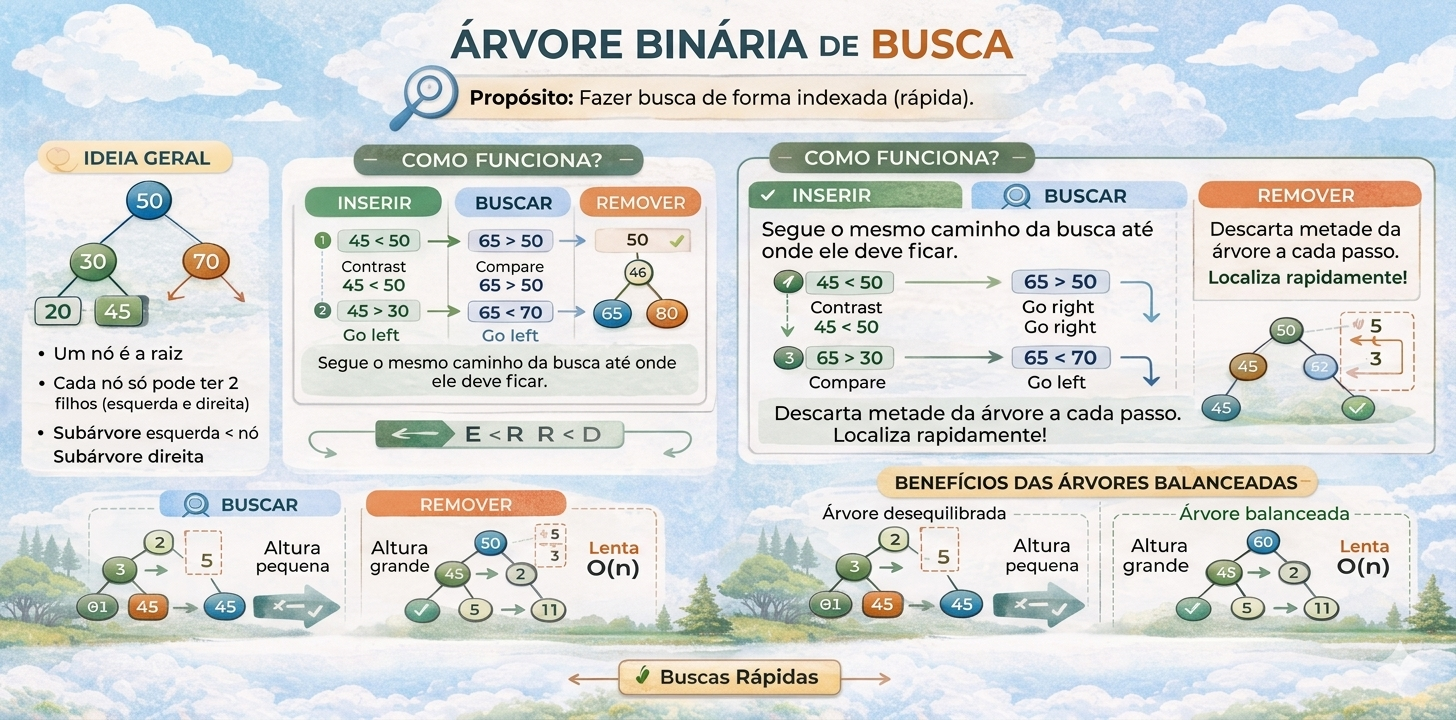